In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import clear_output

sp.init_printing(use_latex=True)

x, nu, t = sp.symbols('x nu t')
phi = sp.exp(-(x - 4 * t)**2 / (4 * nu * (t + 1))) + sp.exp(-(x - 4 * t - 2 * sp.pi)**2 / (4 * nu * (t + 1)))
phi

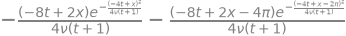

In [2]:
phiprime = phi.diff(x)
phiprime

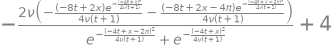

In [3]:
u = -2 * nu * phiprime / phi + 4
u

In [4]:
ufn = sp.utilities.lambdify((t, x, nu), u, modules=['numpy'])
ufn(1, 4, 3)

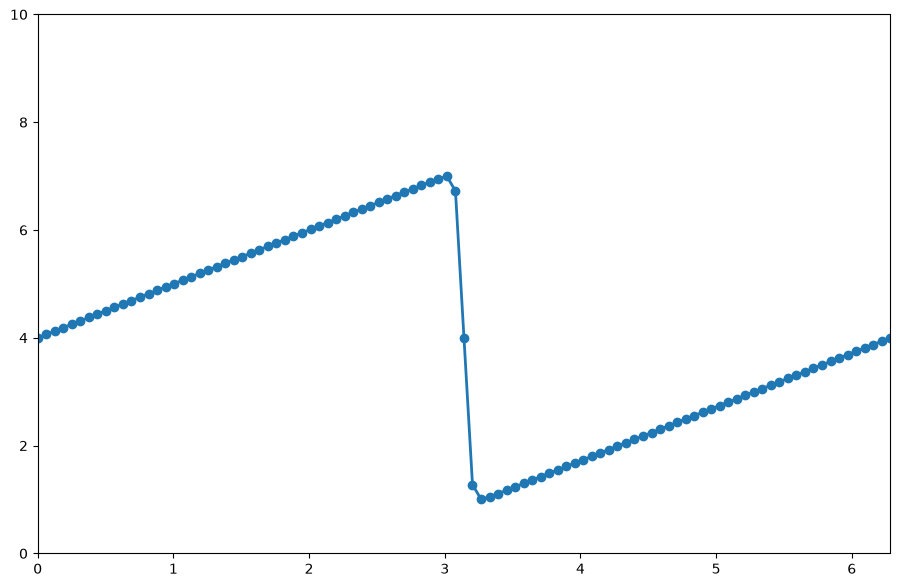

In [5]:
nx = 101
nt = 100

dx = 2 * np.pi / (nx - 1)
nu = 0.07

dt = dx * nu

x = np.linspace(0, 2 * np.pi, nx)
t = 0

u = np.asarray([ufn(t, x0, nu) for x0 in x])

plt.figure(figsize=(11, 7), dpi=100)
plt.plot(x, u, marker='o', lw=2)
plt.axis([0, 2 * np.pi, 0, 10])

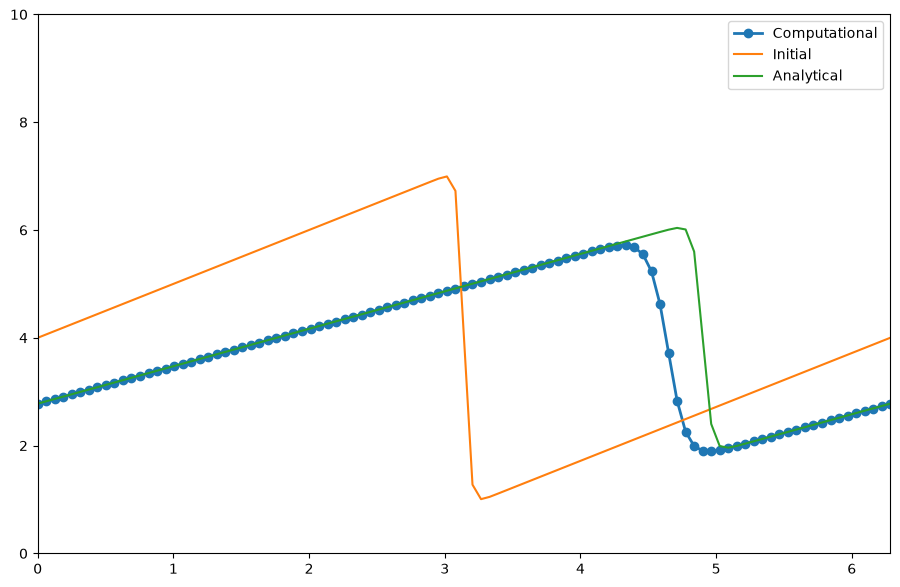

In [6]:
u_initial = u.copy()
u_analytical = np.asarray([ufn(nt * dt, xi, nu) for xi in x])

for n in range(nt):
    un = u.copy()
    for i in range(1, nx - 1):
        u[i] = un[i] - un[i] * dt / dx *(un[i] - un[i-1]) + nu * dt / dx**2 * (un[i+1] - 2 * un[i] + un[i-1])

    u[0] = un[0] - un[0] * dt / dx * (un[0] - un[-2]) + nu * dt / dx**2 * (un[1] - 2 * un[0] + un[-2])
    u[-1] = u[0]

    clear_output(True)
    plt.figure(figsize=(11, 7), dpi=100)
    
    plt.plot(x, u, marker='o', lw=2, label='Computational')
    plt.plot(x, u_initial, label='Initial')
    plt.plot(x, u_analytical, label='Analytical')

    plt.axis([0, 2 * np.pi, 0, 10])
    plt.legend();
    plt.pause(0.01)